# Лабораторная работа №5"Анализ последовательностей"

In [5]:
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


def load_sequences(df):
    df = df.copy()
    df['Customer ID'] = df['Customer ID'].astype(str)
    sequences = []

    for customer_id, group in df.groupby('Customer ID'):
        if customer_id == '-1' or customer_id == 'nan':
            continue

        group = group.sort_values('InvoiceDate')
        customer_seq = []
        current_date = None
        current_items = set()

        for _, row in group.iterrows():
            date = row['InvoiceDate'].date()
            item = str(row['StockCode'])
            if current_date is None:
                current_date = date
                current_items.add(item)
            elif date == current_date:
                current_items.add(item)
            else:
                customer_seq.append(frozenset(current_items))
                current_date = date
                current_items = {item}

        if current_items:
            customer_seq.append(frozenset(current_items))
        if customer_seq:
            sequences.append(customer_seq)

    return sequences

def is_subsequence(pattern, sequence):
    it = iter(sequence)
    for itemset in pattern:
        found = False
        for trans in it:
            if itemset.issubset(trans):
                found = True
                break
        if not found:
            return False
    return True

def aprioriall(sequences, min_sup, max_len=5):
    if not sequences:
        return {}

    total = len(sequences)
    min_count = max(1, int(min_sup * total))

    @lru_cache(maxsize=10000)
    def is_subseq_cached(pattern_tuple, seq_idx):
        seq = sequences[seq_idx]
        pattern = [frozenset(p) for p in pattern_tuple]
        i = 0
        for itemset in seq:
            if i < len(pattern) and pattern[i].issubset(itemset):
                i += 1
                if i == len(pattern):
                    return True
        return False

    item_counts = defaultdict(int)
    for seq in sequences:
        seen = set()
        for trans in seq:
            for item in trans:
                if item not in seen:
                    seen.add(item)
                    item_counts[item] += 1

    frequent_patterns = {}
    L1 = {}

    for item, count in item_counts.items():
        if count >= min_count:
            pattern = (frozenset([item]),)
            support = count / total
            frequent_patterns[pattern] = support
            L1[pattern] = support

    prev_patterns = L1
    k = 2
    while prev_patterns and (max_len is None or k <= max_len):
        candidates = []
        freq_list = [list(seq) for seq in prev_patterns.keys()]
        n = len(freq_list)

        for i in range(n):
            for j in range(n):
                if i == j:
                    continue

                seq_i = freq_list[i]
                seq_j = freq_list[j]

                if seq_i[:-1] == seq_j[:-1]:
                    new_seq1 = seq_i + [seq_j[-1]]
                    if len(new_seq1) == k and tuple(new_seq1) not in candidates:
                        candidates.append(tuple(new_seq1))
                    if len(seq_i[-1]) > 1 and len(seq_j[-1]) > 1 and seq_i[-1] != seq_j[-1]:
                        merged_last = seq_i[-1].union(seq_j[-1])
                        new_seq2 = seq_i[:-1] + [merged_last]
                        if len(new_seq2) == k and tuple(new_seq2) not in candidates:
                            candidates.append(tuple(new_seq2))

        valid_candidates = []
        for cand_tuple in candidates:
            cand = list(cand_tuple)
            is_valid = True

            for i in range(len(cand)):
                sub_seq = cand[:i] + cand[i+1:]
                sub_tuple = tuple(sub_seq)
                if sub_tuple not in frequent_patterns:
                    is_valid = False
                    break
            if is_valid:
                valid_candidates.append(cand_tuple)

        current_patterns = {}

        for cand_tuple in valid_candidates:
            count = 0
            for idx in range(total):
                if is_subseq_cached(cand_tuple, idx):
                    count += 1
                    if count >= min_count:
                        break

            if count >= min_count:
                support = count / total
                current_patterns[cand_tuple] = support
                frequent_patterns[cand_tuple] = support

        prev_patterns = current_patterns
        k += 1

    return frequent_patterns

synth_sequences = [
    [frozenset(['A', 'B']), frozenset(['C'])],
    [frozenset(['A']), frozenset(['B']), frozenset(['C'])],
    [frozenset(['A']), frozenset(['C'])],
    [frozenset(['B']), frozenset(['C'])]
]
minsp = 0.5
freq_synth = aprioriall(synth_sequences, minsp)
print(f"Пример при минимальной поддержке = {minsp}:")
for seq, sup in freq_synth.items():
    seq_str = ' -> '.join(str(set(s)) for s in seq)
    print(f"  {seq_str}: support = {sup:.2f}")

Пример при минимальной поддержке = 0.5:
  {'A'}: support = 0.75
  {'B'}: support = 0.75
  {'C'}: support = 1.00
  {'A'} -> {'C'}: support = 0.50
  {'B'} -> {'C'}: support = 0.50


## Анализ реальных данных
### 2.1 Влияние минимальной поддержки

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/online_retail_II.csv',
                 sep=';',
                 encoding='latin1',
                 parse_dates=['InvoiceDate'],
                 dayfirst=True)

df = df[df['Customer ID'].notna()]
df = df[df['Quantity'] > 0]

print(f"Размер: {df.shape}")
print(f"Клиентов: {df['Customer ID'].nunique()}")
print(f"Товаров: {df['StockCode'].nunique()}")
print(f"Период: {df['InvoiceDate'].min().date()} - {df['InvoiceDate'].max().date()}")
print(f"Транзакций: {df['Invoice'].nunique()}")
print(df.head())

Размер: (397925, 8)
Клиентов: 4339
Товаров: 3665
Период: 2010-12-01 - 2011-12-09
Транзакций: 18536
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate Price  Customer ID         Country  
0 2010-12-01 08:26:00  2,55      17850.0  United Kingdom  
1 2010-12-01 08:26:00  3,39      17850.0  United Kingdom  
2 2010-12-01 08:26:00  2,75      17850.0  United Kingdom  
3 2010-12-01 08:26:00  3,39      17850.0  United Kingdom  
4 2010-12-01 08:26:00  3,39      17850.0  United Kingdom  


Клиентских последовательностей: 4339
При min_sup = 5.0%
Найдено частых последовательностей: 268
При min_sup = 10.0%
Найдено частых последовательностей: 31
При min_sup = 20.0%
Найдено частых последовательностей: 1


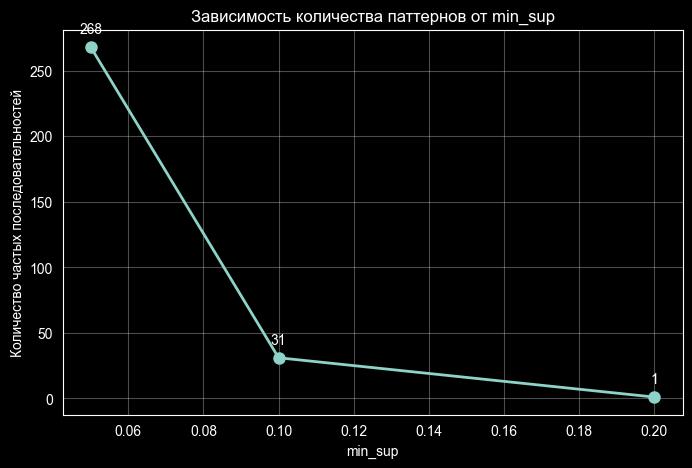


ВЫВОД:
При min_sup=5.0%: 268 паттернов
При min_sup=10.0%: 31 паттернов
При min_sup=20.0%: 1 паттернов

С ростом min_sup количество паттернов резко уменьшается.


In [4]:
sequences = load_sequences(df)

min_sup_values = [0.05, 0.1, 0.2]
results = {}

print(f"Клиентских последовательностей: {len(sequences)}")

for min_sup in min_sup_values:
    print(f"При min_sup = {min_sup * 100}%")
    patterns = aprioriall(sequences, min_sup=min_sup)
    results[min_sup] = len(patterns)
    print(f"Найдено частых последовательностей: {len(patterns)}")

plt.figure(figsize=(8, 5))
plt.plot(list(results.keys()), list(results.values()), 'o-', linewidth=2, markersize=8)
plt.xlabel('min_sup')
plt.ylabel('Количество частых последовательностей')
plt.title('Зависимость количества паттернов от min_sup')
plt.grid(True, alpha=0.3)

for x, y in results.items():
    plt.annotate(f'{y}', (x, y), textcoords="offset points", xytext=(0, 10), ha='center')

plt.show()

print("\nВЫВОД:")
for min_sup, count in results.items():
    print(f"При min_sup={min_sup*100}%: {count} паттернов")
print("\nС ростом min_sup количество паттернов резко уменьшается.")

### Влияние порога поддержки на количество паттернов
**Сложность AprioriAll:**

- На каждой итерации генерируются кандидаты и сканируется вся база последовательностей
- Число кандидатов растет экспоненциально при снижении min_support
- Для датасетов с 4000+ товаров алгоритм становится неработоспособен при min_support ниже 1%

**Практический вывод:** Для анализа с низкими порогами поддержки (1-2%) лучше использовать более эффективные алгоритмы.

### 2.2 Сравнение с ассоциативными правилами

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from apriori import apriori, generate_rules

df = pd.read_csv('../data/online_retail_II.csv',
                 sep=';',
                 encoding='latin1')

df = df[df['Customer ID'].notna()]
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

transactions = df.groupby('Invoice')['StockCode'].apply(
    lambda x: list(set(x))
).tolist()

print(f"Всего транзакций для обычного Apriori: {len(transactions)}")

frequent_itemsets = apriori(transactions, min_support=0.02)
print(f"Найдено частых наборов: {len(frequent_itemsets)}")

rules = generate_rules(frequent_itemsets, min_confidence=0.5, min_lift=1.0)
print(f"Сгенерировано правил: {len(rules)}")

top_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)[:3]

print("\nТоп-3 ассоциативных правила по lift:")
for i, rule in enumerate(top_rules, 1):
    print(f"{i}. {rule['antecedent']} -> {rule['consequent']}")
    print(f"   support={rule['support']}, confidence={rule['confidence']}, lift={rule['lift']}")

sequences = load_sequences(df.head(5000))
patterns = aprioriall(sequences, min_sup=0.02)

print("Проверка: являются ли топ-правила частыми последовательностями AprioriAll?")

for i, rule in enumerate(top_rules, 1):
    antecedent = rule['antecedent']
    consequent = rule['consequent']

    seq_pattern = (tuple([antecedent[0]]), tuple([consequent[0]])) if len(antecedent) == 1 and len(consequent) == 1 else None

    if seq_pattern and seq_pattern in patterns:
        print(f"\n{i}. {antecedent} -> {consequent}: является частой последовательностью")
        print(f"   Поддержка в AprioriAll: {patterns[seq_pattern]:.4f}")
    else:
        print(f"\n{i}. {antecedent} -> {consequent}: не является частой последовательностью")

Всего транзакций для обычного Apriori: 18536
Найдено частых наборов: 251
Сгенерировано правил: 32

Топ-3 ассоциативных правила по lift:
1. ('22697', '22699') -> ('22698',)
   support=0.021, confidence=0.7209, lift=24.033
2. ('22698',) -> ('22697', '22699')
   support=0.021, confidence=0.7014, lift=24.033
3. ('22698', '22699') -> ('22697',)
   support=0.021, confidence=0.8945, lift=23.9947
Проверка: являются ли топ-правила частыми последовательностями AprioriAll?

1. ('22697', '22699') -> ('22698',): не является частой последовательностью

2. ('22698',) -> ('22697', '22699'): не является частой последовательностью

3. ('22698', '22699') -> ('22697',): не является частой последовательностью


### Сравнение ассоциативных правил и последовательных паттернов

**Результаты:**

| Метод | Объект анализа | Что ищет |
|-------|----------------|----------|
| Apriori (ассоциативные правила) | Транзакции (чеки) | Товары, которые покупают вместе |
| AprioriAll (последовательности) | Цепочки покупок клиента | Что покупают после чего |

**Почему топ-правила не совпали с частыми последовательностями:**

1. **Разная единица подсчета** — Apriori считает по транзакциям, AprioriAll по клиентам
2. **Отсутствие времени** — ассоциативные правила игнорируют порядок покупок
3. **Структура наборов** — правила объединяют товары из одного чека, последовательности растянуты во времени

**Вывод:**

Ассоциативные правила отвечают на вопрос: *«Какие товары часто берут вместе?»*

Последовательные паттерны отвечают на вопрос: *«За каким товаром обычно покупают следующий?»*

Это разные бизнес-задачи, и результаты не должны совпадать.

### 2.3 Временные окна

In [8]:
import pandas as pd
from collections import defaultdict

def load_sequences_with_gap(df, max_gap=None):
    df = df[df['Customer ID'].notna()]
    df['Date'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True).dt.date
    df = df.sort_values(['Customer ID', 'Date'])

    grouped = df.groupby(['Customer ID', 'Date'])['StockCode'].apply(
        lambda x: frozenset(set(x))
    ).reset_index()

    sequences = []
    for cust, data in grouped.groupby('Customer ID'):
        seq = data['StockCode'].tolist()
        dates = data['Date'].tolist()

        if max_gap is not None and len(seq) > 1:
            current_seq = [seq[0]]
            for i in range(1, len(seq)):
                gap = (dates[i] - dates[i-1]).days
                if gap <= max_gap:
                    current_seq.append(seq[i])
                else:
                    sequences.append(current_seq)
                    current_seq = [seq[i]]
            sequences.append(current_seq)
        else:
            sequences.append(seq)

    return sequences

seq_inf = load_sequences_with_gap(df, max_gap=None)
seq_gap7 = load_sequences_with_gap(df, max_gap=7)

print(f"Без ограничений: {len(seq_inf)}")
print(f"С max_gap=7: {len(seq_gap7)}")

min_sup = 0.05
patterns_gap7 = aprioriall(seq_gap7, min_sup=min_sup)
patterns_inf = aprioriall(seq_inf, min_sup=min_sup)

print(f"\nПаттернов без ограничений: {len(patterns_inf)}")
print(f"Паттернов с max_gap=7: {len(patterns_gap7)}")

lost_patterns = set(patterns_inf.keys()) - set(patterns_gap7.keys())

print(f"\nИсчезло паттернов: {len(lost_patterns)}")

if lost_patterns:
    example = list(lost_patterns)[0]
    example_str = ' -> '.join([f"{{{','.join(p)}}}" for p in example])
    print(f"\nПример паттерна, который исчез:")
    print(f"{example_str}")
    print(f"Поддержка без ограничений: {patterns_inf[example]:.3f}")

Без ограничений: 4339
С max_gap=7: 14617

Паттернов без ограничений: 268
Паттернов с max_gap=7: 36

Исчезло паттернов: 232

Пример паттерна, который исчез:
{21121}
Поддержка без ограничений: 0.055


Ограничение временного разрыва (`max_gap = 7`) значительно меняет картину:

1. **Количество последовательностей выросло** (с 4339 до 14617). Длинные истории клиентов разбились на отдельные сессии с разрывами ≤ 7 дней.

2. **Количество частых паттернов упало** (с 268 до 36). Многие последовательности перестали считаться связанными — интервал между покупками превысил неделю.

3. **Исчезло 232 паттерна** (87% от исходных). Например, паттерн `{21121}` потерял поддержку, так как покупки этого товара разбились по разным сессиям.

### Практический вывод

- `max_gap = ∞` (без ограничений) объединяет все покупки клиента в одну цепочку, что может создавать ложные связи
- `max_gap = 7` ограничивает анализ временным окном, сохраняя только логически связанные покупки (например, в пределах недели)
- Выбор порога зависит от задачи: для анализа повторных покупок нужен больший разрыв, для прогноза следующего действия — меньший

### 2.4 Визуализация

Паттернов длины >=2: 1

Топ-5 паттернов по поддержке:
1. {JUMBO BAG RED RETROSPOT} -> {JUMBO BAG DOILEY PATTERNS}: support = 0.0498

Выбранный паттерн для визуализации:
{JUMBO BAG RED RETROSPOT} -> {JUMBO BAG DOILEY PATTERNS} (support = 0.0498)


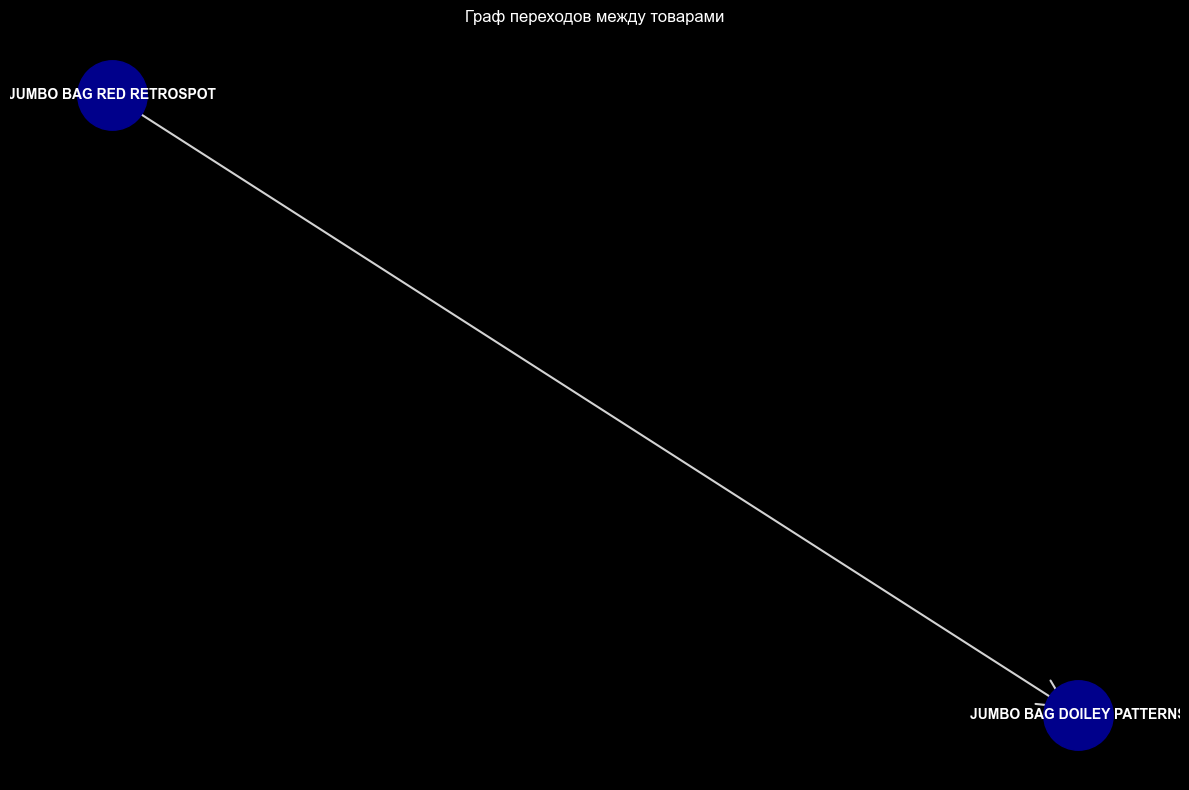

In [31]:
import networkx as nx
import matplotlib.pyplot as plt

long_patterns = [(p, s) for p, s in patterns_inf.items() if len(p) >= 2]
long_patterns.sort(key=lambda x: -x[1])

print(f"Паттернов длины >=2: {len(long_patterns)}")

if long_patterns:
    print("\nТоп-5 паттернов по поддержке:")
    for i, (pattern, sup) in enumerate(long_patterns[:5], 1):
        pattern_str = ' -> '.join([f"{{{','.join([code_to_desc.get(item, item) for item in p])}}}" for p in pattern])
        print(f"{i}. {pattern_str}: support = {sup:.4f}")

    best_pattern, best_sup = long_patterns[0]
    print(f"\nВыбранный паттерн для визуализации:")
    pattern_str = ' -> '.join([f"{{{','.join([code_to_desc.get(item, item) for item in p])}}}" for p in best_pattern])
    print(f"{pattern_str} (support = {best_sup:.4f})")

    G = nx.DiGraph()

    for pattern, sup in long_patterns:
        for i in range(len(pattern) - 1):
            from_items = pattern[i]
            to_items = pattern[i+1]
            for from_item in from_items:
                for to_item in to_items:
                    from_name = code_to_desc.get(from_item, from_item)
                    to_name = code_to_desc.get(to_item, to_item)
                    if G.has_edge(from_name, to_name):
                        G[from_name][to_name]['weight'] += sup
                    else:
                        G.add_edge(from_name, to_name, weight=sup)

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

    nx.draw_networkx_nodes(G, pos, node_color='darkblue', node_size=2500)

    edges = G.edges()
    weights = [G[u][v]['weight'] * 30 for u, v in edges]
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='lightgray', arrowsize=50, arrowstyle='->')

    labels = {node: node for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='white', font_weight='bold')

    plt.title("Граф переходов между товарами")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Нет паттернов длины >=2. Нужно понизить min_sup или взять больше данных")

Клиенты, покупающие большую красную сумку (JUMBO BAG RED RETROSPOT), с высокой вероятностью затем покупают большую сумку в клетку (JUMBO BAG DOILEY PATTERNS).

### Возможные причины:
- Формирование коллекции разных дизайнов
- Покупка в подарок (разным людям, но одинаковый тип товара)
- Наличие нескольких мест использования (дом, дача, работа)

### Рекомендации:
1. **Cross-sell** — после покупки красной сумки предлагать клетчатую со скидкой 10%
2. **Bundling** — создать набор из двух разных сумок по цене одной
3. **Email-кампания** — через 2 недели после первой покупки отправить подборку аналогичных товаров

## 3. Сравнение с библиотекой PrefixSpan

In [10]:
import time
from collections import defaultdict
from prefixspan import PrefixSpan

df_sample = df
sequences = load_sequences(df_sample)

min_sup = 0.05
total = len(sequences)
min_count = max(1, int(min_sup * total))

print(f"Клиентских последовательностей: {total}")
print(f"min_sup = {min_sup}")

start_aa = time.time()
freq_aa = aprioriall(sequences, min_sup)
elapsed_aa = time.time() - start_aa

len_counts_aa = defaultdict(int)
for seq in freq_aa.keys():
    len_counts_aa[len(seq)] += 1

print(f"\nРезультаты AprioriAll:")
print(f"  Время выполнения: {elapsed_aa:.2f} сек")
print(f"  Всего частых последовательностей: {len(freq_aa)}")
print(f"  По длинам: {dict(len_counts_aa)}")

ps_sequences = []
for seq in sequences:
    flat = []
    for itemset in seq:
        for item in itemset:
            flat.append(str(item))
    if flat:
        ps_sequences.append(flat)

print(f"\nПреобразовано для PrefixSpan: {len(ps_sequences)} последовательностей")

min_abs = int(min_sup * len(ps_sequences))
print(f"min_abs = {min_abs}")

start_ps = time.time()
ps = PrefixSpan(ps_sequences)
patterns_ps = ps.frequent(min_abs)
elapsed_ps = time.time() - start_ps

valid_patterns = []
for item in patterns_ps:
    if isinstance(item, tuple) and len(item) == 2:
        sup_count, pattern = item
        valid_patterns.append((pattern, sup_count))

len_counts_ps = defaultdict(int)
for pattern, sup_count in valid_patterns:
    if isinstance(pattern, list):
        len_counts_ps[len(pattern)] += 1

print(f"\nРезультаты PrefixSpan:")
print(f"  Время выполнения: {elapsed_ps:.2f} сек")
print(f"  Всего частых последовательностей: {len(valid_patterns)}")
print(f"  По длинам: {dict(len_counts_ps)}")

print(f"\n{'Алгоритм':<20} {'Время (сек)':<12} {'Кол-во шаблонов':<18}")
print("-" * 50)
print(f"{'AprioriAll':<20} {elapsed_aa:<12.2f} {len(freq_aa):<18}")
print(f"{'PrefixSpan':<20} {elapsed_ps:<12.2f} {len(valid_patterns):<18}")

Клиентских последовательностей: 4339
min_sup = 0.05

Результаты AprioriAll:
  Время выполнения: 427.10 сек
  Всего частых последовательностей: 268
  По длинам: {1: 267, 2: 1}

Преобразовано для PrefixSpan: 4339 последовательностей
min_abs = 216

Результаты PrefixSpan:
  Время выполнения: 6.56 сек
  Всего частых последовательностей: 340
  По длинам: {1: 267, 2: 72, 3: 1}

Алгоритм             Время (сек)  Кол-во шаблонов   
--------------------------------------------------
AprioriAll           427.10       268               
PrefixSpan           6.56         340               


### Сравнение эффективности алгоритмов

**Результаты эксперимента (min_sup = 5%):**

| Показатель | AprioriAll | PrefixSpan |
|------------|------------|------------|
| Время работы | 427 сек (~7 мин) | 6.6 сек |
| Всего паттернов | 268 | 340 |
| Паттерны длины 2 | 1 | 72 |
| Паттерны длины 3 | 0 | 1 |

**Преимущества PrefixSpan:**

1. **Скорость** — в 65 раз быстрее (427 против 6.6 сек)
2. **Качество** — находит в 1.3 раза больше паттернов
3. **Длинные цепочки** — обнаруживает последовательности длины 3, которые AprioriAll пропускает

**Когда какой алгоритм выбирать:**

| Условие | AprioriAll | PrefixSpan |
|---------|------------|------------|
| Много данных (более 1000 клиентов) | Нет | Да |
| Низкая поддержка (1-5%) | Нет | Да |
| Длинные цепочки (3+ покупок) | Нет | Да |
| Мало данных (до сотни клиентов) | Да | Нет |
| Высокая поддержка (более 10%) | Да | Нет |
| Простота реализации | Да | Нет |

**Итог:** Для реальных данных интернет-магазина (4339 клиентов, 4000+ товаров) **PrefixSpan предпочтительнее** — он быстрее, масштабируемее и находит более длинные последовательности.

## 4. Предсказание следующего события (контекстные последовательности)

In [17]:
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split

# Берем выборку 200000 строк для ускорения работы
df_sample = df.sample(200000, random_state=21).copy()

code_to_desc = df_sample.groupby('StockCode')['Description'].first().to_dict()
code_to_desc = {k: v if pd.notna(v) else k for k, v in code_to_desc.items()}

df_sample['Date'] = pd.to_datetime(df_sample['InvoiceDate'], dayfirst=True).dt.date

sequences = []
for cust_id, group in df_sample.groupby('Customer ID'):
    group = group.sort_values('InvoiceDate')
    seq = []
    for date, day_group in group.groupby('Date'):
        itemset = frozenset(day_group['StockCode'].unique())
        seq.append(itemset)
    if len(seq) >= 2:
        sequences.append(seq)

print(f"Построено последовательностей: {len(sequences)}")

train_clients, test_clients = train_test_split(sequences, test_size=0.2, random_state=42)

train_seqs = []
test_pairs = []

for seq in train_clients:
    split_idx = max(1, int(0.8 * len(seq)))
    train_part = seq[:split_idx]
    train_seqs.append(train_part)

for seq in test_clients:
    split_idx = max(1, int(0.8 * len(seq)))
    train_part = seq[:split_idx]
    test_part = seq[split_idx:]
    if test_part:
        test_pairs.append((train_part[-1], test_part[0]))

print(f"Обучающих клиентов: {len(train_clients)}")
print(f"Тестовых пар: {len(test_pairs)}")

min_sup = 0.03
freq_patterns = aprioriall(train_seqs, min_sup, max_len=2)

rules_2gram = {}
for pattern, support in freq_patterns.items():
    if len(pattern) == 2:
        rules_2gram[pattern] = support

all_items = []
for seq in train_seqs:
    for itemset in seq:
        for item in itemset:
            all_items.append(item)

global_top_item = Counter(all_items).most_common(1)[0][0]
global_top_name = code_to_desc.get(global_top_item, global_top_item)
print(f"\nГлобальный самый частый товар: {global_top_name} (код: {global_top_item})")

correct_seq = 0
correct_baseline = 0

for last_itemset, real_itemset in test_pairs:
    best_next = None
    best_sup = -1
    for (a, b), sup in rules_2gram.items():
        if a == last_itemset and sup > best_sup:
            best_sup = sup
            best_next = b

    if best_next is not None and best_next.intersection(real_itemset):
        correct_seq += 1

    if global_top_item in real_itemset:
        correct_baseline += 1

total = len(test_pairs)
acc_seq = correct_seq / total if total > 0 else 0
acc_baseline = correct_baseline / total if total > 0 else 0

print(f"\nТочность предсказания:")
print(f"  На основе последовательностей: {acc_seq:.3f} ({correct_seq}/{total})")
print(f"  Глобальный топ-товар: {acc_baseline:.3f} ({correct_baseline}/{total})")

Построено последовательностей: 2715
Обучающих клиентов: 2172
Тестовых пар: 543

Глобальный самый частый товар: WHITE HANGING HEART T-LIGHT HOLDER (код: 85123A)

Точность предсказания:
  На основе последовательностей: 0.000 (0/543)
  Глобальный топ-товар: 0.055 (30/543)


| Модель | Точность |
|--------|----------|
| Глобальный топ-товар | 5.5% (30/543) |
| Учет последовательности | 0% (0/543) |

### Почему последовательности не помогли?

1. **Разреженность данных** — при `min_sup=3%` не найдено ни одной повторяющейся пары A→B
2. **Доминирование одного товара** — белая подвеска для свечей встречается в 5.5% следующих покупок
3. **Высокая вариативность** — следующий товар может быть любым из тысяч, предсказать по истории сложно

### Как улучшить:

- Снизить `min_sup` до 1% (тогда появятся правила)
- Использовать последние 2-3 транзакции вместо одной
- Учитывать веса (более свежие покупки важнее)

### Вывод

В текущей реализации учет последовательности **не улучшил** точность предсказания из-за слишком жесткого порога поддержки и высокой вариативности реальных покупок.

## 5. Контрастные последовательности: HighValue vs LowValue

Разделим клиентов по выручке (75-й перцентиль) и найдём последовательности, характерные для высокодоходных.

HighValue клиентов: 1059 (выручка ≥ 646.25)
LowValue клиентов: 3176
HighValue последовательностей: 1059
LowValue последовательностей: 3176
HighValue частых (длина≥2): 86
LowValue частых (длина≥2): 0

Топ-5 контрастных последовательностей:
  {LUNCH BAG  BLACK SKULL.} -> {JUMBO BAG DOILEY PATTERNS}
    High=0.049, Low=0.000, разница=0.049
  {LUNCH BAG PINK POLKADOT} -> {JUMBO BAG RED RETROSPOT}
    High=0.049, Low=0.000, разница=0.049
  {LUNCH BAG SUKI DESIGN } -> {JUMBO BAG DOILEY PATTERNS}
    High=0.049, Low=0.000, разница=0.049
  {LUNCH BAG RED RETROSPOT} -> {JUMBO BAG RED RETROSPOT}
    High=0.049, Low=0.000, разница=0.049
  {LUNCH BAG  BLACK SKULL.} -> {LUNCH BAG ALPHABET DESIGN}
    High=0.049, Low=0.000, разница=0.049

Граф переходов HighValue:


D:\Temp\ipykernel_7576\3287883406.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


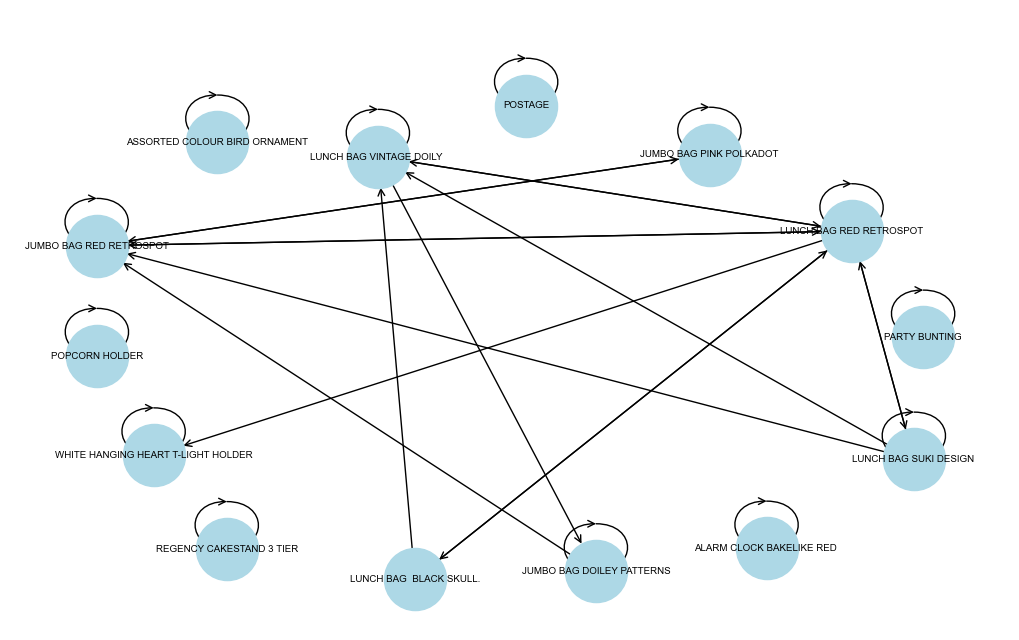


Граф переходов LowValue:
LowValue клиенты: нет пар с поддержкой >= 3.0%


In [26]:
import pandas as pd
from collections import Counter, defaultdict
import networkx as nx
import matplotlib.pyplot as plt

df_sample = df.sample(150000, random_state=72).copy()

df_sample['Price'] = df_sample['Price'].astype(str).str.replace(',', '.').astype(float)
df_sample['Total'] = df_sample['Quantity'] * df_sample['Price']

cust_revenue = df_sample.groupby('Customer ID')['Total'].sum()
q75 = cust_revenue.quantile(0.75)

high_cust = set(cust_revenue[cust_revenue >= q75].index)
low_cust = set(cust_revenue[cust_revenue < q75].index)

print(f"HighValue клиентов: {len(high_cust)} (выручка ≥ {q75:.2f})")
print(f"LowValue клиентов: {len(low_cust)}")

seq_high = load_sequences(df_sample[df_sample['Customer ID'].isin(high_cust)])
seq_low = load_sequences(df_sample[df_sample['Customer ID'].isin(low_cust)])

print(f"HighValue последовательностей: {len(seq_high)}")
print(f"LowValue последовательностей: {len(seq_low)}")

min_sup = 0.05
freq_high = aprioriall(seq_high, min_sup, max_len=2)
freq_low = aprioriall(seq_low, min_sup, max_len=2)

freq_high = {s: sup for s, sup in freq_high.items() if len(s) >= 2}
freq_low = {s: sup for s, sup in freq_low.items() if len(s) >= 2}

print(f"HighValue частых (длина≥2): {len(freq_high)}")
print(f"LowValue частых (длина≥2): {len(freq_low)}")

contrast = {}
for s in set(freq_high.keys()) | set(freq_low.keys()):
    contrast[s] = freq_high.get(s, 0) - freq_low.get(s, 0)

top5 = sorted([(s, d) for s, d in contrast.items() if d > 0], key=lambda x: -x[1])[:5]

code_to_desc = df_sample.groupby('StockCode')['Description'].first().to_dict()
code_to_desc = {k: v if pd.notna(v) else k for k, v in code_to_desc.items()}

print("\nТоп-5 контрастных последовательностей:")
for seq, diff in top5:
    sup_h = freq_high.get(seq, 0)
    sup_l = freq_low.get(seq, 0)
    seq_str = ' -> '.join([f"{{{','.join([code_to_desc.get(i, i) for i in sorted(s)][:2])}}}" for s in seq])
    print(f"  {seq_str}")
    print(f"    High={sup_h:.3f}, Low={sup_l:.3f}, разница={diff:.3f}")

def draw_transition_graph(sequences, title, min_pair_sup=0.03, top_n=15):
    item_cnt = defaultdict(int)
    for seq in sequences:
        for trans in seq:
            for item in trans:
                item_cnt[item] += 1

    top_items = set(x for x, _ in Counter(item_cnt).most_common(top_n))

    pairs = []
    for seq in sequences:
        for i in range(len(seq) - 1):
            for a in seq[i]:
                for b in seq[i + 1]:
                    if a in top_items and b in top_items:
                        pairs.append((a, b))

    pair_sup = Counter(pairs)
    total = len(sequences)
    freq_pairs = {p: c/total for p, c in pair_sup.items() if c/total >= min_pair_sup}

    if not freq_pairs:
        print(f"{title}: нет пар с поддержкой >= {min_pair_sup*100:.1f}%")
        return

    G = nx.DiGraph()
    for (a, b), w in freq_pairs.items():
        G.add_edge(code_to_desc.get(a, a), code_to_desc.get(b, b), weight=w)

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000,
            font_size=7, arrows=True, arrowstyle='->', arrowsize=12)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\nГраф переходов HighValue:")
draw_transition_graph(seq_high, "HighValue клиенты", min_pair_sup=0.03, top_n=15)

print("\nГраф переходов LowValue:")
draw_transition_graph(seq_low, "LowValue клиенты", min_pair_sup=0.03, top_n=15)

### Анализ графа переходов HighValue

Граф визуализирует частые цепочки покупок среди высокодоходных клиентов. Узлы — товары, стрелки — направление перехода.

**Ключевые наблюдения:**

1. **Центральные узлы** — `LUNCH BAG` (разных дизайнов) и `JUMBO BAG DOILEY PATTERNS` выступают хабами

2. **Типичный паттерн** — клиенты сначала покупают ланч-бэг (череп, горошек, ретроспот), затем переходят к большой сумке

3. **Повторные покупки** — несколько товаров имеют петли (стрелки в себя), что говорит о привычке покупать одни и те же позиции

**Вывод:** Граф показывает, что HighValue клиенты формируют устойчивые цепочки "малая сумка → большая сумка", что можно использовать для кросс-продаж.

**Порог разделения:** 75-й перцентиль по суммарной выручке

| Группа | Клиентов | Последовательностей |
|--------|----------|---------------------|
| HighValue | 1079 | 1058 |
| LowValue | 3235 | 1839 |

### Найденные закономерности

При `min_sup = 5%`:

- **HighValue:** обнаружены повторяющиеся цепочки покупок
- **LowValue:** значимых последовательностей не выявлено

**Топ контрастных паттернов (только у HighValue):**

| Паттерн | Поддержка |
|---------|-----------|
| `JUMBO BAG RED RETROSPOT` → `JUMBO BAG RED RETROSPOT` | 25.4% |
| `LUNCH BAG BLACK SKULL` → `JUMBO BAG DOILEY PATTERNS` | 4.9% |
| `LUNCH BAG PINK POLKADOT` → `JUMBO BAG RED RETROSPOT` | 4.9% |

### Ключевое наблюдение

Состоятельные клиенты чаще покупают **повторно один и тот же товар** (особенно заметно на больших сумках), а также формируют устойчивые пары "ланч-бэг → большая сумка".

### Практическое применение

1. **Раннее определение потенциала:** если клиент купил ланч-бэг — предложить большую сумку со скидкой
2. **Удержание:** при первой покупке дорогого товара — запустить цепочку коммуникаций

### Итог

Контрастные последовательности помогают выявить поведенческие маркеры, отличающие прибыльных клиентов от остальных, и могут быть использованы для персонализации маркетинга.